## Customer Segmentation using PCA and K-Means

This notebook performs customer segmentation on the iFood dataset using **K-Means clustering** and **Principal Component Analysis (PCA)**.  
We aim to identify patterns in customer behavior and visualize clusters in reduced dimensions.

#  Import Libraries

Import Required Libraries
We will use:
- `pandas` & `numpy` for data handling
- `matplotlib.pyplot` for visualization
- `sklearn` for scaling, PCA, clustering, and evaluation

In [28]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Load Dataset
- Load `Marketing data.csv`.
- Keep only numeric columns for clustering.
- Drop missing values to ensure clean analysis.

In [44]:
df = pd.read_csv("marketing data.csv")
df = df.select_dtypes(include=[np.number]).copy()
df.dropna(inplace=True)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2205, 39)


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


#  Feature Scaling

Standardize Features
- Scale features using `StandardScaler` so all have **mean=0** and **variance=1**.
- This prevents features with larger scales from dominating K-Means.

In [30]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Elbow Method (Before PCA)
- Compute inertia for `k = 1 to 10`.
- Plot inertia vs. number of clusters.
- Helps determine the optimal K (“elbow point”) for clustering.

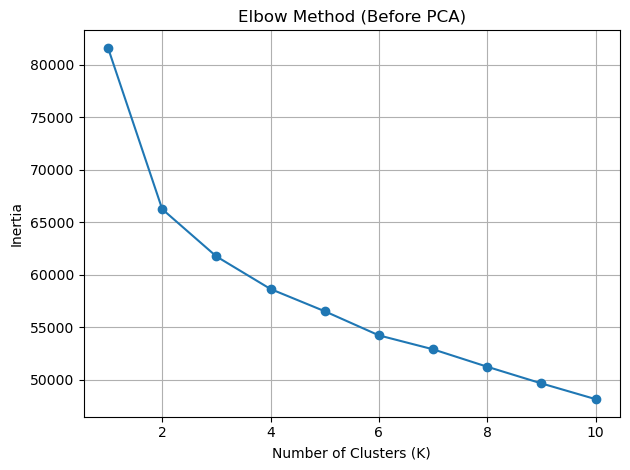

In [31]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method (Before PCA)")
plt.grid()
plt.tight_layout()
plt.show()

# K-Means Clustering (Before PCA)
- Fit K-Means using `k=3` (from Elbow method).
- Compute **Silhouette Score** to evaluate clustering quality.

In [32]:
kmeans_raw = KMeans(n_clusters=3, random_state=42, n_init=20)
labels_raw = kmeans_raw.fit_predict(scaled_data)

silhouette_raw = silhouette_score(scaled_data, labels_raw)
print("Silhouette Score (Before PCA):", round(silhouette_raw, 4))

Silhouette Score (Before PCA): 0.1699


# PCA Analysis
- Fit PCA on scaled data.
- Plot **cumulative explained variance** to see how many components capture most variance.

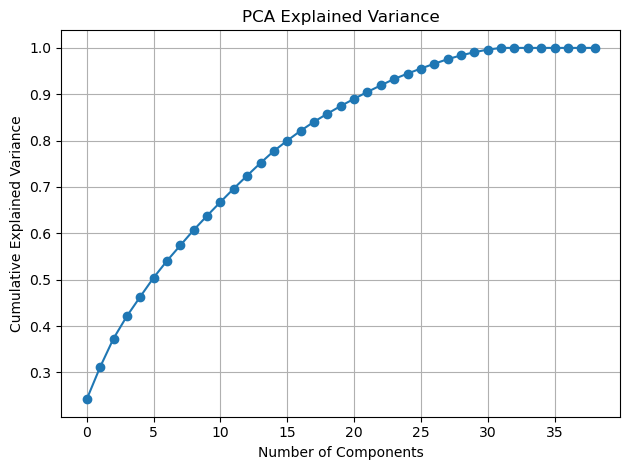

In [33]:
pca_full = PCA()
pca_full.fit(scaled_data)

plt.figure()
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.tight_layout()
plt.show()

#  PCA Transformation (2 Components)

Reduce Data to 2 Principal Components
- For visualization and simplified clustering, reduce to 2 dimensions.

In [34]:
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(scaled_data)

# Elbow Method (After PCA)
- Repeat inertia calculation on PCA-reduced data.
- Compare with original Elbow method to see effect of dimensionality reduction.

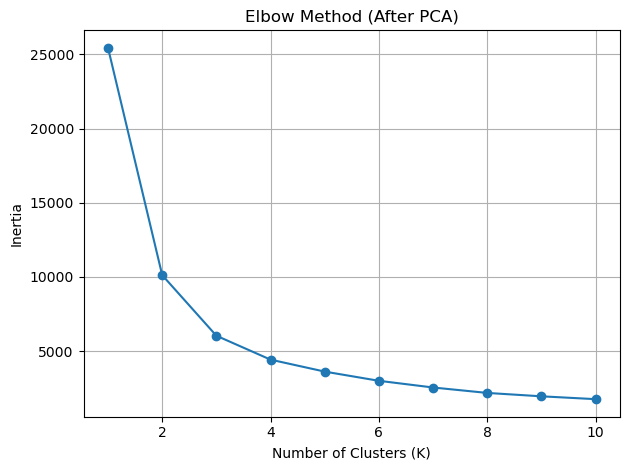

In [35]:
inertia_pca = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans.fit(pca_data)
    inertia_pca.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia_pca, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method (After PCA)")
plt.grid()
plt.tight_layout()
plt.show()

# K-Means Clustering (After PCA)
- Fit K-Means on 2D PCA data.
- Compute **Silhouette Score** to evaluate performance after PCA.

In [36]:
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=20)
labels_pca = kmeans_pca.fit_predict(pca_data)

silhouette_pca = silhouette_score(pca_data, labels_pca)
print("Silhouette Score (After PCA):", round(silhouette_pca, 4))

Silhouette Score (After PCA): 0.578


# Cluster Visualization (PCA Space)
- Scatter plot clusters using 2 PCA components.
- Mark cluster centroids with `X`.

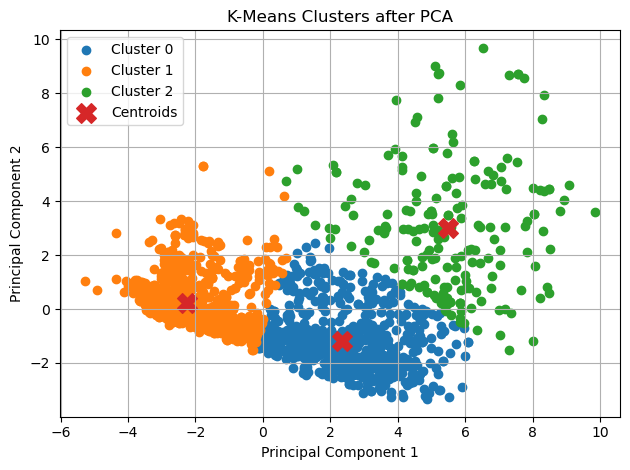

In [37]:
plt.figure()
for cluster in np.unique(labels_pca):
    plt.scatter(
        pca_data[labels_pca == cluster, 0],
        pca_data[labels_pca == cluster, 1],
        label=f"Cluster {cluster}"
    )

centroids = kmeans_pca.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, label='Centroids')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters after PCA")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Add Cluster Labels to Original Data
- Save cluster assignments to original dataframe for further analysis.

In [38]:
df_clustered = df.copy()
df_clustered['Cluster'] = labels_pca
df_clustered.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Cluster
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,1,0,0,1529,1441,0,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,1,0,0,21,15,0,1
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,0,0,1,0,0,734,692,0,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,0,0,1,0,0,48,43,0,1
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,1,407,392,0,1


# Cluster Summary
- Compute **mean feature values per cluster** to understand cluster characteristics.

In [39]:
cluster_summary = df_clustered.groupby('Cluster').mean()
print(cluster_summary.round(2))

           Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  \
Cluster                                                              
0        67949.81     0.08      0.54    49.92    520.25      52.92   
1        37390.42     0.72      0.54    48.77     85.70       6.08   
2        79875.84     0.05      0.20    47.05    892.37      54.53   

         MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds  \
Cluster                                                                     
0                 307.29            74.69             53.28         74.21   
1                  33.50             9.11              5.93         21.50   
2                 462.32            79.06             62.20         72.50   

         ...  marital_Together  marital_Widow  education_2n Cycle  \
Cluster  ...                                                        
0        ...              0.26           0.05                0.08   
1        ...              0.26           0.03           

# Top Features Differences Across Clusters
Top Features Across Clusters
- Identify top 5 features with highest variance across clusters.
- Visualize with a bar chart.

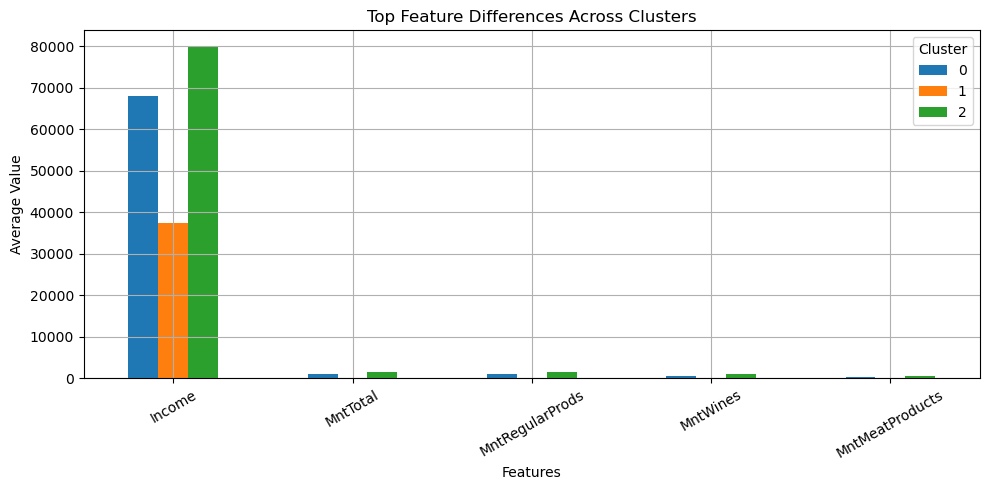

In [40]:
top_features = cluster_summary.var().sort_values(ascending=False).head(5).index
cluster_summary[top_features].T.plot(kind='bar', figsize=(10, 5))

plt.title("Top Feature Differences Across Clusters")
plt.xlabel("Features")
plt.ylabel("Average Value")
plt.xticks(rotation=30)
plt.legend(title="Cluster")
plt.grid()
plt.tight_layout()
plt.show()

# Interpretation
- Review top features to understand each cluster’s profile.

In [41]:
for cluster in cluster_summary.index:
    print(f"\nCluster {cluster} (Top Features):")
    top_features_cluster = cluster_summary.loc[cluster].sort_values(ascending=False).head(5)
    print(top_features_cluster)


Cluster 0 (Top Features):
Income             67949.806109
Customer_Days       2536.482072
MntTotal            1008.435591
MntRegularProds      934.228420
MntWines             520.249668
Name: 0, dtype: float64

Cluster 1 (Top Features):
Income             37390.417530
Customer_Days       2496.132271
MntTotal             140.317928
MntRegularProds      118.815936
MntWines              85.696414
Name: 1, dtype: float64

Cluster 2 (Top Features):
Income             79875.842640
Customer_Days       2527.548223
MntTotal            1550.482234
MntRegularProds     1477.979695
MntWines             892.365482
Name: 2, dtype: float64


#  Final Comparison
Compare Silhouette Scores
- Evaluate effect of PCA on clustering quality.

In [42]:
print("Silhouette Score Before PCA :", round(silhouette_raw, 4))
print("Silhouette Score After PCA  :", round(silhouette_pca, 4))

if silhouette_pca > silhouette_raw:
    print("\nConclusion: PCA improved clustering performance.")
else:
    print("\nConclusion: PCA had limited or no improvement.")

Silhouette Score Before PCA : 0.1699
Silhouette Score After PCA  : 0.578

Conclusion: PCA improved clustering performance.
